> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 4. Data and Exploratory Data Analysis

*Scope:* Where data comes from, what kinds of variables it holds, and how to interrogate it before a single model is fitted.

Exploratory data analysis is the step everyone is tempted to skip and nobody who has been burned skips
twice. Its purpose is not to produce charts. It is to answer, before any model exists:

* What is actually in this data, as opposed to what the schema claims?
* Which variables plausibly carry signal, and which are noise, identifiers or leakage?
* What will break the moment a model touches it — missing values, impossible values, mixed types?
* Is the question even answerable with these columns?

Chapter 5 fixes what this chapter finds. Chapter 6 builds on what it suggests.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 110)
sns.set_theme(style="whitegrid")

customers = pd.read_csv("data/customers.csv")
print(customers.shape)

(1012, 14)


### 4.1 Kinds of Data and Kinds of Variables

Every decision downstream — which plot, which encoding (Chapter 6), which distance metric (14.2), which
metric (8.4 vs 8.5) — follows from a variable's type. Getting this table right first is not pedantry; it is
the cheapest way to avoid a whole class of later mistakes.

| Type | Sub-type | Example here | Encoded how (Ch. 6) | Plotted how |
|---|---|---|---|---|
| **Numeric** | Continuous | `monthly_charges` | Scaled (5.5) | Histogram, boxplot |
| | Discrete / count | `support_tickets` | Scaled, or binned (6.3) | Bar, histogram |
| **Categorical** | Nominal (no order) | `city`, `gender` | One-hot (6.2) | Bar, count plot |
| | Ordinal (ordered) | `plan` | Ordinal encoding (6.2) | Bar, ordered |
| | Binary | `churned` | As-is, 0/1 | Bar |
| **Datetime** | — | `signup_date` | Decomposed (6.5) | Line, over time |
| **Text** | — | `cancellation_reason` | TF-IDF or category (6.6) | Frequency table |
| **Identifier** | — | `customer_id` | **Dropped** | Not plotted |

The last row is a rule, not a suggestion. An identifier is unique per row, so it can only ever be
memorized, never generalized from.

In [2]:
print("unique values per column:")
uniq = customers.nunique().sort_values()
print(uniq.to_string())
print(f"\nrows: {len(customers)}")

unique values per column:
churned                   2
plan                      3
cancellation_reason       5
gender                    6
support_tickets           7
city                      8
satisfaction_score       10
last_login_days          48
age                      58
tenure_months            72
signup_date             785
monthly_charges         868
total_charges           974
customer_id            1000

rows: 1012


Reading that list top-down is itself a typing exercise: 2 unique values is binary, a handful is
categorical, and a count equal to (or near) the row count is an identifier or a continuous measurement.
`customer_id` has 1000 unique values in 1012 rows — unique except for the duplicate rows found in 3.9.1.

In [3]:
n = len(customers)
kinds = {}
for col in customers.columns:
    k = customers[col].nunique()
    if k / n > 0.95:
        kinds[col] = "identifier or continuous"
    elif k == 2:
        kinds[col] = "binary"
    elif k <= 12:
        kinds[col] = "categorical"
    else:
        kinds[col] = "numeric / high-cardinality"

for col, kind in kinds.items():
    print(f"{col:<22} {customers[col].dtype!s:<10} {kind}")

customer_id            str        identifier or continuous
signup_date            str        numeric / high-cardinality
age                    float64    numeric / high-cardinality
gender                 str        categorical
city                   str        categorical
plan                   str        categorical
tenure_months          int64      numeric / high-cardinality
monthly_charges        float64    numeric / high-cardinality
total_charges          str        identifier or continuous
support_tickets        int64      categorical
last_login_days        int64      numeric / high-cardinality
satisfaction_score     float64    categorical
churned                int64      binary
cancellation_reason    str        categorical


That heuristic gets you started and is wrong in four instructive places:

| Column | Heuristic says | Actually is |
|---|---|---|
| `signup_date` | numeric / high-cardinality | A **datetime** — must be decomposed, not used raw (6.5) |
| `total_charges` | identifier or continuous | Continuous, but typed `str` because of nine blank entries (3.3.1) |
| `support_tickets` | categorical (7 levels) | A **count** — genuinely numeric, and orderable |
| `satisfaction_score` | categorical (10 levels) | **Ordinal** — ordered, so 8 really is more than 3 |

**Cardinality is a hint; the schema and the domain decide.** The last two rows are the ones that matter
most in practice: a low-cardinality integer can be a category (`plan` encoded 0/1/2) or a count
(`support_tickets`), and nothing in the data distinguishes them — only knowing what the column *means*
does.

**Common mistake — feeding an encoded category to a model as a number.** If `city` is stored as 0–7, a
model reading it numerically concludes that Jaipur (7) is "greater than" Kolkata (0) and that the midpoint
between them means something. It does not. Only genuinely ordered variables — `plan`, a rating, a size —
may be encoded as ordered integers, and 6.2 covers the alternatives for the rest.

In [4]:
# "Ordinal" is a claim about the data, and it has to be true.
ordered_ok = {"Basic": 0, "Standard": 1, "Premium": 2}      # Basic < Standard < Premium: a real order
ordered_wrong = {c: i for i, c in enumerate(sorted(customers["city"].unique()))}

print("plan  ->", ordered_ok)          # meaningful: 2 really is "more" than 0
print("city  ->", ordered_wrong)        # meaningless: Pune is not 6x Bengaluru

plan  -> {'Basic': 0, 'Standard': 1, 'Premium': 2}
city  -> {'Bengaluru': 0, 'Chennai': 1, 'Delhi': 2, 'Hyderabad': 3, 'Jaipur': 4, 'Kolkata': 5, 'Mumbai': 6, 'Pune': 7}


### 4.2 Getting Data: bundled datasets, synthetic generators and files

Three sources, three purposes. Nothing in this material downloads anything (§0.7).

| Source | Use it for | Cost |
|---|---|---|
| `sklearn.datasets.load_*` | A realistic small problem where the answer is roughly known | Small, clean, unrepresentatively tidy |
| `sklearn.datasets.make_*` | A controlled problem where the *truth* is known exactly | Synthetic; only as realistic as you make it |
| A file (`data/*.csv`) | Real mess: types, missingness, duplicates | You have to clean it |

| Bundled loader | Task | Shape |
|---|---|---|
| `load_iris` | 3-class classification | 150 × 4 |
| `load_wine` | 3-class classification | 178 × 13 |
| `load_breast_cancer` | Binary classification | 569 × 30 |
| `load_digits` | 10-class, image-like | 1797 × 64 |
| `load_diabetes` | Regression | 442 × 10 |

In [5]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)      # as_frame=True returns pandas objects with real column names
print("shape :", wine.data.shape)
print("target:", wine.target.value_counts().sort_index().to_dict())   # {0: 59, 1: 71, 2: 48}
print("\nfirst 4 features:", list(wine.feature_names[:4]))
print(wine.data.iloc[:3, :4].round(2))

shape : (178, 13)
target: {0: 59, 1: 71, 2: 48}

first 4 features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash']
   alcohol  malic_acid   ash  alcalinity_of_ash
0    14.23        1.71  2.43               15.6
1    13.20        1.78  2.14               11.2
2    13.16        2.36  2.67               18.6


The `make_*` generators matter more than they first appear: because you specify the truth, you can check
whether a method recovers it. That is how 7.2's feature selection and 9.2's bias–variance simulation are
validated at all.

| Generator | Produces |
|---|---|
| `make_regression` | Linear regression data with a known number of informative features |
| `make_classification` | Classification data with controllable informative/redundant/noise features |
| `make_blobs` | Isotropic Gaussian clusters — the shape k-means is built for (20.2) |
| `make_moons`, `make_circles` | Non-linearly separable shapes — where linear models fail (16.5) |

In [6]:
from sklearn.datasets import make_classification

X_syn, y_syn = make_classification(
    n_samples=500, n_features=10,
    n_informative=3,     # only 3 columns actually carry signal...
    n_redundant=2,       # ...2 more are linear combinations of those
    n_repeated=0,
    random_state=RANDOM_STATE,
)
# The remaining 5 are pure noise - and we know exactly which situation we built.
print("X:", X_syn.shape, "| informative 3, redundant 2, noise 5")
print("class balance:", np.bincount(y_syn))

X: (500, 10) | informative 3, redundant 2, noise 5
class balance: [249 251]


### 4.3 First Contact: shape, dtypes and the summary triage

3.3.1 introduced `head`/`info`/`describe`. The EDA version adds two things: **describe the categoricals
too**, and **write down what you find**.

In [7]:
print(customers.describe(include="number").round(2).T[["count", "mean", "std", "min", "max"]])

                     count   mean    std   min     max
age                  953.0  38.04  13.04   0.0  199.00
tenure_months       1012.0  36.43  20.81   1.0   72.00
monthly_charges      982.0  40.48  17.13  15.0   89.71
support_tickets     1012.0   1.26   1.12   0.0    6.00
last_login_days     1012.0  12.40   8.49   0.0   51.00
satisfaction_score   912.0   7.32   1.69   1.0   10.00
churned             1012.0   0.14   0.35   0.0    1.00


In [8]:
print(customers.describe(include=["object", "string"]).T)

                    count unique         top freq
customer_id          1012   1000      C00077    2
signup_date          1012    785  2020-02-23    4
gender                965      6           M  341
city                 1012      8     Kolkata  228
plan                 1012      3       Basic  461
total_charges        1012    974                9
cancellation_reason   142      5     service   32


The categorical summary earns its place immediately: `top` and `freq` show the most common value, and
`unique` shows cardinality. `gender` reporting **6 unique values** for a two-valued concept is the whole
finding, visible without a single plot.

Four numbers to read off the numeric summary every time:

In [9]:
summary = customers.describe(include="number").T
checks = pd.DataFrame({
    "missing": len(customers) - summary["count"],
    "min": summary["min"],
    "max": summary["max"],
    "std_is_zero": summary["std"] == 0,
})
print(checks)

                    missing   min     max  std_is_zero
age                    59.0   0.0  199.00        False
tenure_months           0.0   1.0   72.00        False
monthly_charges        30.0  15.0   89.71        False
support_tickets         0.0   0.0    6.00        False
last_login_days         0.0   0.0   51.00        False
satisfaction_score    100.0   1.0   10.00        False
churned                 0.0   0.0    1.00        False


| Read | Means | Action |
|---|---|---|
| `count` below the row count | Missing values | 5.2 |
| `min` or `max` implausible | Data-entry error or a sentinel value | 5.3 |
| `std` exactly 0 | A constant column — zero information | Drop it (7.2) |
| `mean` far from `50%` | Skew; a long tail on one side | 4.4, 5.6 |

Here `age` has 59 missing, a minimum of 0 and a maximum of 199 — both impossible for a subscriber, and
both would silently corrupt any mean, any scaler and any distance computation.

#### 4.3.1 Sentinel values

A specific trap the summary catches: some systems encode "missing" as a *number* — `-1`, `0`, `999`,
`-9999`. These are not detected by `.isna()`, and they are catastrophic because they are arithmetically
valid. A minimum of exactly `-1` or `0` on a quantity that cannot be either is the tell.

In [10]:
# 0 is a legitimate value for some columns and impossible for others - only the domain decides.
for col in ["age", "support_tickets", "last_login_days", "monthly_charges"]:
    zeros = (customers[col] == 0).sum()
    print(f"{col:<20} zeros: {zeros:>4}   plausible? "
          f"{'no  <- investigate' if col == 'age' else 'yes'}")

age                  zeros:    1   plausible? no  <- investigate
support_tickets      zeros:  282   plausible? yes
last_login_days      zeros:    2   plausible? yes
monthly_charges      zeros:    0   plausible? yes


### 4.4 Univariate Analysis

One variable at a time. The question is always the same: **what shape is this, and is the shape sensible?**

| Shape seen | Usually means | Consequence |
|---|---|---|
| Roughly symmetric | Well behaved | Nothing to do |
| Right-skewed (long tail) | Money, counts, durations | Consider a log transform (5.6) |
| **Bimodal / multimodal** | Two populations mixed together | Find the variable that separates them |
| Spike at one value | Zero-inflation or a sentinel (4.3.1) | Investigate before imputing |
| Heaping at round numbers | Self-reported or rounded data | Usually harmless; note it |
| Uniform | Often an artefact or an ID | Suspicious in a natural measurement |

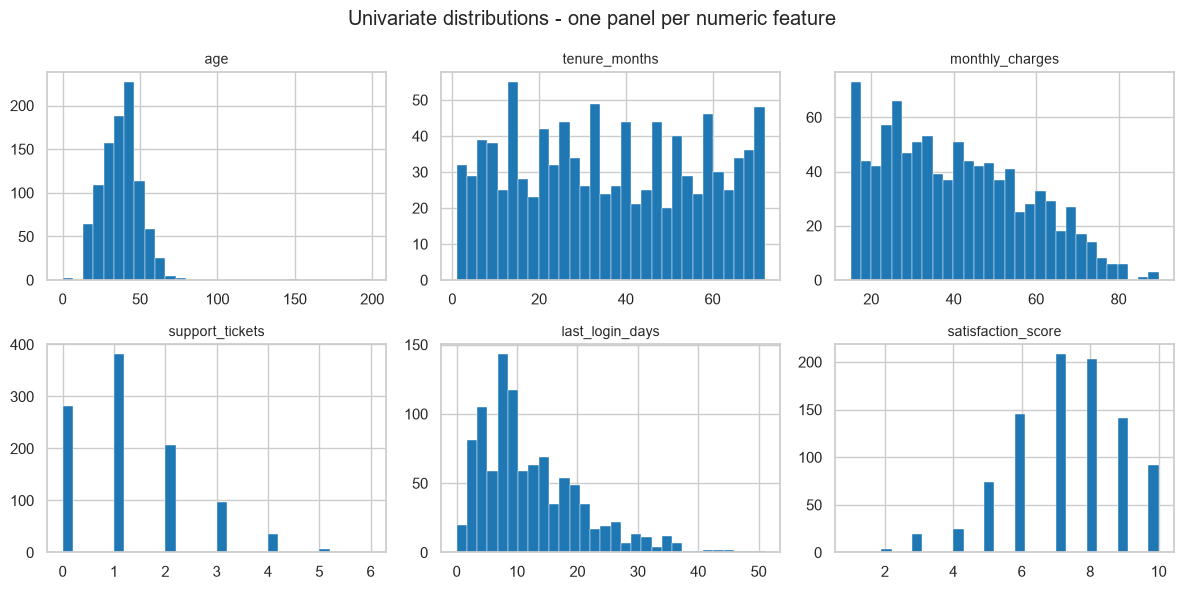

In [11]:
numeric_cols = ["age", "tenure_months", "monthly_charges", "support_tickets",
                "last_login_days", "satisfaction_score"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(customers[col].dropna(), bins=30, color="tab:blue", edgecolor="white", linewidth=0.3)
    ax.set_title(col, fontsize=10)
fig.suptitle("Univariate distributions - one panel per numeric feature")
fig.tight_layout()
plt.show()

Four findings from one figure:

1. **`age`** is a normal-looking bump plus a couple of impossible points stretching the axis to 199 — the
   giveaway is that the bump occupies only the left fifth of the plot.
2. **`monthly_charges`** is clearly **multimodal**. That is not noise: it is three plans at three price
   points, mixed into one column. 4.5 confirms it.
3. **`support_tickets`** and **`last_login_days`** are right-skewed counts, the classic shape for a log or
   square-root transform (5.6).
4. **`tenure_months`** is close to uniform, which in real data would be suspicious — here it is an artefact
   of how `data/customers.csv` was generated, and worth naming as such rather than over-interpreting.

Quantify the shape rather than eyeballing it:

In [12]:
shape_stats = pd.DataFrame({
    "skew": customers[numeric_cols].skew().round(2),
    "kurtosis": customers[numeric_cols].kurtosis().round(2),
    "mean": customers[numeric_cols].mean().round(2),
    "median": customers[numeric_cols].median().round(2),
})
print(shape_stats)

                    skew  kurtosis   mean  median
age                 2.69     28.90  38.04   38.00
tenure_months       0.06     -1.22  36.43   35.00
monthly_charges     0.41     -0.73  40.48   38.47
support_tickets     0.87      0.49   1.26    1.00
last_login_days     1.24      1.69  12.40   10.00
satisfaction_score -0.47      0.08   7.32    7.00


| Skew | Reading |
|---|---|
| ≈ 0 | Symmetric |
| > +1 | Strongly right-skewed — long tail of large values |
| < −1 | Strongly left-skewed |

`age`'s skew of 2.69 and kurtosis of 28.9 are caused entirely by four impossible values. Kurtosis is the
more sensitive alarm of the two — it weights extreme deviations to the fourth power, so a handful of absurd
rows moves it enormously while the median does not budge. Both are more reliable outlier alarms than a
histogram, because neither depends on the bin width. Recomputing after excluding the impossible values
shows how much of the "shape" was four rows:

In [13]:
plausible_age = customers["age"].where(customers["age"].between(16, 100))
print(f"age skew, as loaded : {customers['age'].skew():>6.2f}   kurtosis {customers['age'].kurtosis():>7.2f}")
print(f"age skew, plausible : {plausible_age.skew():>6.2f}   kurtosis {plausible_age.kurtosis():>7.2f}")
# 2.69 -> 0.20 and 28.90 -> -0.31: the column was well behaved all along, four rows were not

age skew, as loaded :   2.69   kurtosis   28.90
age skew, plausible :   0.20   kurtosis   -0.32


For categorical variables the equivalent is `value_counts`, and the thing to look for is **rare
categories** — levels with so few rows that any statistic computed on them is noise (and that may not
appear in the training split at all, 6.2).

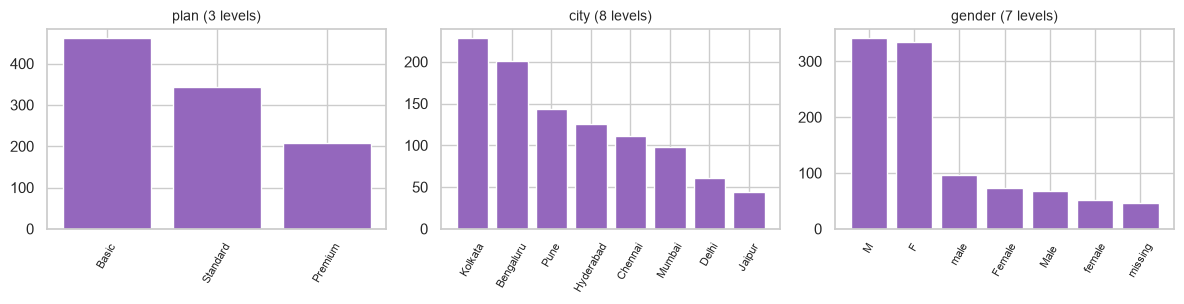

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, col in zip(axes, ["plan", "city", "gender"]):
    counts = customers[col].value_counts(dropna=False)
    labels = [str(v) if pd.notna(v) else "missing" for v in counts.index]   # NaN needs its own label
    ax.bar(labels, counts.values, color="tab:purple")
    ax.set_title(f"{col} ({counts.size} levels)", fontsize=10)
    ax.tick_params(axis="x", rotation=60, labelsize=8)
fig.tight_layout()
plt.show()

### 4.5 Bivariate Analysis

Two variables at a time. The right tool depends on the pair of types:

| Pair | Tool | Statistic |
|---|---|---|
| Numeric × numeric | Scatter plot | Pearson / Spearman (2.8.2) |
| Numeric × categorical | Boxplot, or grouped histogram | Group means, ANOVA F |
| Categorical × categorical | Cross-tabulation, stacked bar | Chi-square (3.9.1) |
| Anything × the target | Whatever fits the pair | 4.7 |

Start with the multimodality found in 4.4 — the hypothesis was that `plan` explains it.

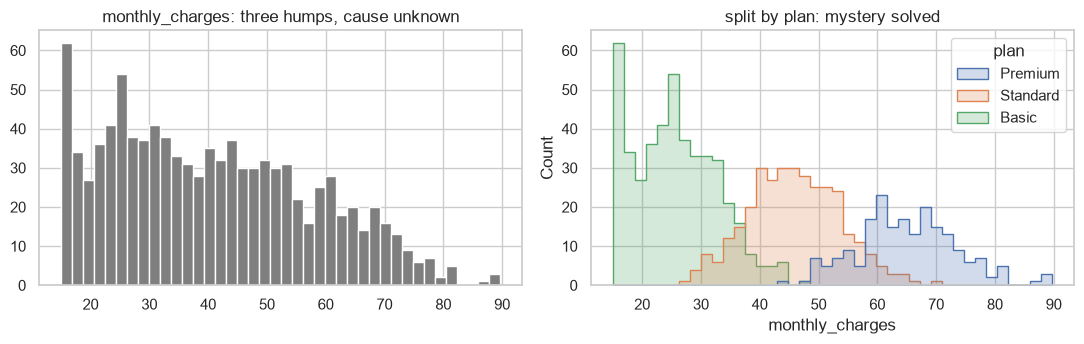

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(customers["monthly_charges"].dropna(), bins=40, color="tab:gray")
axes[0].set_title("monthly_charges: three humps, cause unknown")

sns.histplot(data=customers, x="monthly_charges", hue="plan", bins=40,
             element="step", ax=axes[1])
axes[1].set_title("split by plan: mystery solved")

fig.tight_layout()
plt.show()

The three modes are the three plans. This matters beyond tidiness: a model given `monthly_charges` alone
has to *discover* that structure, whereas one given `plan` as well is handed it. It also means the two
columns are strongly related, which is a multicollinearity risk for linear models (11.7).

In [16]:
print(customers.groupby("plan")["monthly_charges"].agg(["count", "mean", "std", "min", "max"]).round(2))

          count   mean   std    min    max
plan                                      
Basic       451  25.63  7.21  15.00  47.52
Premium     201  65.07  8.47  43.37  89.71
Standard    330  45.80  7.77  27.90  69.48


Numeric × numeric, with the target as colour — a scatter that answers a question rather than decorating:

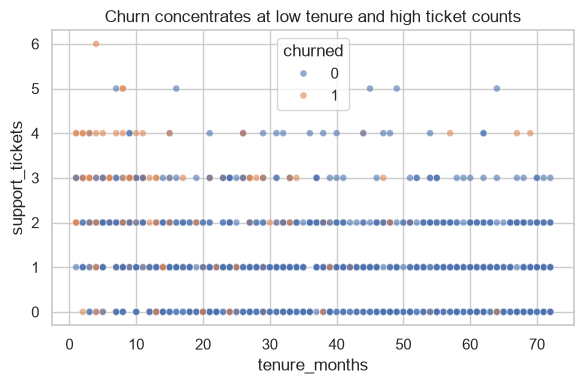

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=customers, x="tenure_months", y="support_tickets",
                hue="churned", alpha=0.6, s=25, ax=ax)
ax.set_title("Churn concentrates at low tenure and high ticket counts")
fig.tight_layout()
plt.show()

Categorical × categorical, as rates rather than counts. Counts are almost always the wrong view: a large
category will dominate a stacked bar regardless of its rate.

In [18]:
by_city = pd.crosstab(customers["city"], customers["churned"], normalize="index").round(3)
by_city.columns = ["stayed", "churned"]
print(by_city.sort_values("churned", ascending=False))
print("\ncity sizes:", customers['city'].value_counts().to_dict())

           stayed  churned
city                      
Delhi       0.770    0.230
Kolkata     0.846    0.154
Chennai     0.847    0.153
Hyderabad   0.864    0.136
Bengaluru   0.866    0.134
Pune        0.882    0.118
Mumbai      0.888    0.112
Jaipur      0.909    0.091

city sizes: {'Kolkata': 228, 'Bengaluru': 201, 'Pune': 144, 'Hyderabad': 125, 'Chennai': 111, 'Mumbai': 98, 'Delhi': 61, 'Jaipur': 44}


**Common mistake — reading a rate computed on a tiny group.** Jaipur's churn rate is computed from about 50
customers, so its standard error is roughly $\sqrt{p(1-p)/n} \approx 0.05$ — a ±10 percentage-point band at
two standard errors. Ranking cities by a rate this noisy produces a "worst city" that changes every month.
Always put the group size next to the rate (2.8.3, 3.9.1).

In [19]:
rates = customers.groupby("city")["churned"].agg(["count", "mean"])
rates["std_error"] = np.sqrt(rates["mean"] * (1 - rates["mean"]) / rates["count"])
rates["ci_low"] = (rates["mean"] - 2 * rates["std_error"]).clip(0)
rates["ci_high"] = rates["mean"] + 2 * rates["std_error"]
print(rates.round(3).sort_values("mean", ascending=False))

           count   mean  std_error  ci_low  ci_high
city                                               
Delhi         61  0.230      0.054   0.122    0.337
Kolkata      228  0.154      0.024   0.106    0.201
Chennai      111  0.153      0.034   0.085    0.222
Hyderabad    125  0.136      0.031   0.075    0.197
Bengaluru    201  0.134      0.024   0.086    0.182
Pune         144  0.118      0.027   0.064    0.172
Mumbai        98  0.112      0.032   0.048    0.176
Jaipur        44  0.091      0.043   0.004    0.178


Every confidence interval overlaps every other one. There is no evidence here that any city differs from
any other, and reporting a ranking would be inventing a finding.

### 4.6 Multivariate Analysis and Correlation Structure

More than two variables at once. Two standard views:

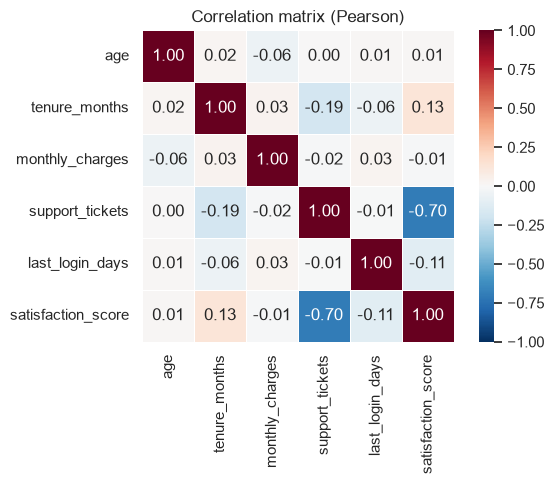

In [20]:
corr = customers[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation matrix (Pearson)")
fig.tight_layout()
plt.show()

Read a correlation heatmap for two different things:

* **Feature–target correlation** — candidate signal.
* **Feature–feature correlation** — redundancy, which hurts linear-model interpretation (11.7) and wastes
  capacity everywhere else (7.2).

Here `satisfaction_score` correlates **−0.70** with `support_tickets`: unhappy customers file tickets,
which is sensible and also means the two columns say much the same thing. Everything else is below 0.19 in
absolute value, so there is no serious redundancy elsewhere.

In [21]:
# Pull out the strongly related pairs programmatically rather than squinting at the grid.
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack()
             .rename("correlation")
             .reset_index()
             .rename(columns={"level_0": "a", "level_1": "b"}))
print(pairs.reindex(pairs["correlation"].abs().sort_values(ascending=False).index).head(5).round(3))

                  a                   b  correlation
23  support_tickets  satisfaction_score       -0.696
9     tenure_months     support_tickets       -0.185
11    tenure_months  satisfaction_score        0.131
29  last_login_days  satisfaction_score       -0.114
2               age     monthly_charges       -0.058


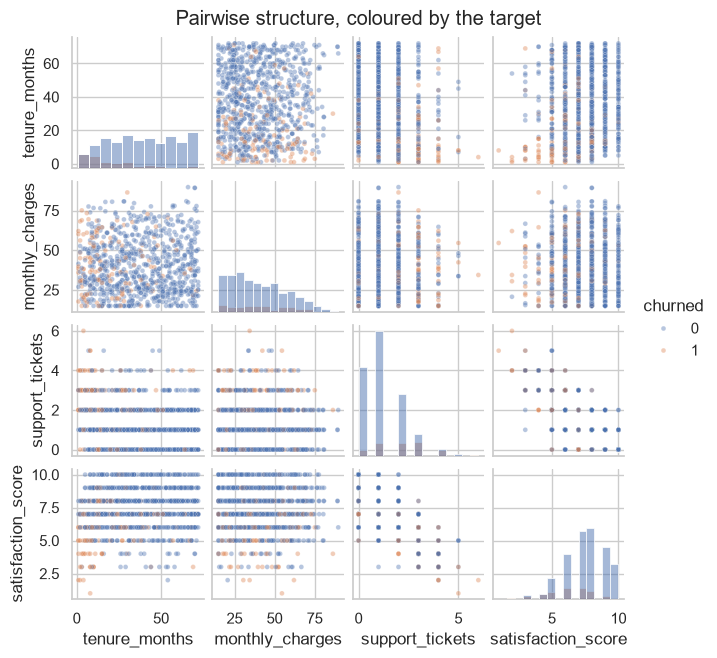

In [22]:
subset = customers[["tenure_months", "monthly_charges", "support_tickets",
                    "satisfaction_score", "churned"]].dropna()
g = sns.pairplot(subset, hue="churned", diag_kind="hist",
                 plot_kws={"alpha": 0.4, "s": 12}, height=1.6)
g.figure.suptitle("Pairwise structure, coloured by the target", y=1.02)
plt.show()

#### 4.6.1 Simpson's paradox

The reason multivariate analysis is not optional: **an association can reverse when a third variable is
taken into account.** This is not a curiosity — it is a live risk whenever groups of different sizes and
different base rates are pooled.

In [23]:
# Two departments. Within EACH, treatment B has the higher success rate.
records = []
for dept, n_a, rate_a, n_b, rate_b in [("easy", 80, 0.90, 20, 0.95),
                                       ("hard", 20, 0.20, 80, 0.30)]:
    for treat, n, rate in (("A", n_a, rate_a), ("B", n_b, rate_b)):
        successes = int(round(n * rate))
        records += [{"dept": dept, "treatment": treat, "success": 1}] * successes
        records += [{"dept": dept, "treatment": treat, "success": 0}] * (n - successes)

sim = pd.DataFrame(records)

print("WITHIN each department:")
print(sim.groupby(["dept", "treatment"])["success"].mean().round(3))
print("\nPOOLED across departments:")
print(sim.groupby("treatment")["success"].mean().round(3))

WITHIN each department:
dept  treatment
easy  A            0.90
      B            0.95
hard  A            0.20
      B            0.30
Name: success, dtype: float64

POOLED across departments:
treatment
A    0.76
B    0.43
Name: success, dtype: float64


Treatment B wins in the easy department (0.95 vs 0.90) and wins in the hard department (0.30 vs 0.20), and
**loses overall** (0.43 vs 0.76). Nothing is miscalculated: B was mostly applied in the hard department,
where everything scores badly, and A was mostly applied in the easy one.

The lesson for EDA is exact: **a marginal statistic can point the opposite way from every conditional
one.** Whenever a group-level rate is going to inform a decision, check it within the obvious confounders
before believing it. This is also the honest limit of model interpretation — 24.4 returns to it.

### 4.7 Target Analysis

The target deserves its own pass, because three of its properties dictate the entire rest of the project.

**1. Its balance** decides the metric (8.5) and whether Chapter 22 applies.

In [24]:
counts = customers["churned"].value_counts().sort_index()
print(counts)
print(f"positive rate: {customers['churned'].mean():.1%}")
print(f"imbalance ratio: 1 : {counts[0] / counts[1]:.1f}")

churned
0    870
1    142
Name: count, dtype: int64
positive rate: 14.0%
imbalance ratio: 1 : 6.1


**2. Its relationship to each feature** gives a first, cheap ranking of what might matter. For a binary
target, the ROC AUC of *each feature used alone* is a good single number: 0.5 means no information, and
distance from 0.5 in either direction means signal.

In [25]:
from sklearn.metrics import roc_auc_score

single_feature_auc = {}
for col in numeric_cols:
    ok = customers[col].notna()
    auc = roc_auc_score(customers.loc[ok, "churned"], customers.loc[ok, col])
    single_feature_auc[col] = auc

ranking = (pd.Series(single_feature_auc)
             .rename("auc")
             .to_frame()
             .assign(signal=lambda d: (d["auc"] - 0.5).abs())
             .sort_values("signal", ascending=False)
             .round(3))
print(ranking)

                      auc  signal
tenure_months       0.223   0.277
support_tickets     0.725   0.225
satisfaction_score  0.281   0.219
last_login_days     0.539   0.039
age                 0.470   0.030
monthly_charges     0.515   0.015


`tenure_months` at 0.24 is as informative as a feature at 0.76 would be — the direction is simply inverted
(longer tenure, less churn). Ranking by distance from 0.5 rather than by the raw AUC is what makes the
comparison honest.

**3. Whether anything predicts it too well.** A single feature with an AUC near 1.0 is almost never good
news; it is 1.8.1's leakage arriving as a number.

In [26]:
has_reason = customers["cancellation_reason"].notna().astype(int)
print("AUC of 'cancellation_reason is present':",
      round(roc_auc_score(customers["churned"], has_reason), 3))   # 1.0 -> perfect. Too perfect.

AUC of 'cancellation_reason is present': 1.0


An AUC of exactly **1.000** from a single column means the column *is* the answer, recorded after the fact.
The rule of thumb worth carrying: **treat any single feature above about 0.95 AUC as guilty until proven
innocent**, and ask the 1.8.1 question — would this value exist, in this form, at the moment the prediction
is needed? For `cancellation_reason` the answer is no, and it must be dropped before modelling. 22.7 is the
full taxonomy.

In [27]:
modelling_frame = customers.drop(columns=["customer_id", "cancellation_reason"])
print("dropped: customer_id (identifier, 4.1), cancellation_reason (leakage)")
print("remaining columns:", list(modelling_frame.columns))

dropped: customer_id (identifier, 4.1), cancellation_reason (leakage)


remaining columns: ['signup_date', 'age', 'gender', 'city', 'plan', 'tenure_months', 'monthly_charges', 'total_charges', 'support_tickets', 'last_login_days', 'satisfaction_score', 'churned']


### 4.8 What EDA Is Really For

EDA is not a phase that produces a deliverable of charts. It is the process of forming and killing
hypotheses about the data, and it is finished when you can answer these:

| Question | Answered by | Feeds into |
|---|---|---|
| What type is each column, really? | 4.1, 4.3 | Encoding choices (6.2) |
| What is missing, and is the missingness itself informative? | 4.3 | 5.2 |
| Which values are impossible rather than merely extreme? | 4.3, 4.4 | 5.3 |
| Which features are redundant with each other? | 4.6 | 7.2, 11.7 |
| Which features plausibly carry signal? | 4.7 | 6.7, 7.2 |
| Is any feature leaking the target? | 4.7 | 22.7 |
| Is the target balanced? | 4.7 | 8.5, Ch. 22 |
| Is a baseline already good enough? | 1.6, 8.8 | Whether to continue at all |

**When to stop.** When further looking stops changing what you would do next. EDA has strongly diminishing
returns, and the failure mode of enjoying it is a folder of 60 charts and no decisions.

#### 4.8.1 The uncomfortable part: EDA is itself a mild form of leakage

Every choice you make after looking at the whole dataset — which features to keep, which outliers to
remove, which transform to apply — was informed by the test set. The test score afterwards is therefore
slightly optimistic. This is not hypothetical; it is why 5.1 insists the split comes first.

In strict practice: **split first, explore the training set only, and touch the test set once.** The
demonstrations above deliberately used the whole file, because their point was to show what the techniques
reveal; the worked case in 4.9 does it the right way round so the correct habit is on the page too.

| Rigour | What you do | When it is appropriate |
|---|---|---|
| Strict | Split, then explore train only | Anything whose score will be reported or acted on |
| Pragmatic | Explore everything, but make *decisions* only from train | Common in practice; state it honestly |
| Wrong | Explore everything, tune against the test score | Produces a number that means nothing |

The middle row is what most real projects do, and it is defensible as long as it is disclosed. The bottom
row is how a model that scored 0.94 in a notebook scores 0.71 in production.

### 4.9 In Practice

#### 4.9.1 A worked case: a 30-minute data-quality review

The request: *"Here's the customer export. Can we predict churn from it?"* The deliverable is not a model.
It is a short, written answer to three questions — **is the data usable, what has to be fixed, and what
should the first model use?** — produced in under an hour, before anyone commits to a project.

**Step 0 — split first (4.8.1).** Everything below looks at training data only.

In [28]:
from sklearn.model_selection import train_test_split

data = pd.read_csv("data/customers.csv").drop_duplicates()

train_df, test_df = train_test_split(
    data, test_size=0.2, stratify=data["churned"], random_state=RANDOM_STATE
)
print(f"train {train_df.shape}   test {test_df.shape}")
print(f"churn rate - train {train_df['churned'].mean():.3f}, test {test_df['churned'].mean():.3f}")

train (800, 14)   test (200, 14)
churn rate - train 0.141, test 0.140


**Step 1 — a data-quality table.** One row per column, mechanically generated, is worth more than any
number of individual checks because nothing gets skipped.

In [29]:
def quality_report(df):
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "missing_%": round(100 * s.isna().mean(), 1),
            "unique": s.nunique(),
            "top_share_%": round(100 * s.value_counts(normalize=True).iloc[0], 1) if s.nunique() else 0,
        })
    return pd.DataFrame(rows).set_index("column")


report = quality_report(train_df)
print(report)

                       dtype  missing_%  unique  top_share_%
column                                                      
customer_id              str        0.0     800          0.1
signup_date              str        0.0     659          0.5
age                  float64        5.8      57          5.2
gender                   str        4.5       6         36.1
city                     str        0.0       8         21.6
plan                     str        0.0       3         45.4
tenure_months          int64        0.0      72          2.4
monthly_charges      float64        3.0     702          5.0
total_charges            str        0.0     779          1.0
support_tickets        int64        0.0       7         37.5
last_login_days        int64        0.0      47          7.5
satisfaction_score   float64        9.2      10         23.0
churned                int64        0.0       2         85.9
cancellation_reason      str       85.9       5         22.1


Three problems are now visible as table rows rather than as things someone had to think to check:

* `total_charges` is `str` — it should be numeric (blank entries, 3.3.1).
* `satisfaction_score` is 9.8% missing, `age` 5.6%, `gender` 4.6% — all need a 5.2 decision.
* `cancellation_reason` is 85.9% missing, and 4.7 already established it is leakage.

**Step 2 — impossible values.** Distinguish "extreme but real" from "cannot be true", because they get
different treatment (5.3).

In [30]:
rules = {
    "age": (16, 100),
    "tenure_months": (0, 120),
    "monthly_charges": (0, 500),
    "support_tickets": (0, 50),
    "satisfaction_score": (1, 10),
}

for col, (lo, hi) in rules.items():
    bad = train_df[col].notna() & ~train_df[col].between(lo, hi)
    if bad.any():
        offenders = sorted(float(v) for v in train_df.loc[bad, col].unique())
        print(f"{col}: {bad.sum()} value(s) outside [{lo}, {hi}] -> {offenders}")
    else:
        print(f"{col}: all values within [{lo}, {hi}]")

age: 4 value(s) outside [16, 100] -> [0.0, 1.0, 150.0, 199.0]
tenure_months: all values within [0, 120]
monthly_charges: all values within [0, 500]
support_tickets: all values within [0, 50]
satisfaction_score: all values within [1, 10]


**Step 3 — a signal shortlist.** Rank features by univariate association with the target, so the first
model starts from evidence rather than intuition. Mutual information is the right tool here because,
unlike correlation, it catches non-monotonic relationships (2.8.2).

In [31]:
from sklearn.feature_selection import mutual_info_classif

feature_cols = ["age", "tenure_months", "monthly_charges", "support_tickets",
                "last_login_days", "satisfaction_score"]

fit_frame = train_df[feature_cols + ["churned"]].dropna()
mi = mutual_info_classif(fit_frame[feature_cols], fit_frame["churned"],
                         random_state=RANDOM_STATE)

shortlist = (pd.Series(mi, index=feature_cols, name="mutual_info")
               .sort_values(ascending=False)
               .to_frame()
               .round(4))
print(shortlist)

                    mutual_info
tenure_months            0.0744
support_tickets          0.0528
satisfaction_score       0.0409
monthly_charges          0.0273
age                      0.0119
last_login_days          0.0000


Two things to read here. The ranking agrees with 4.7's AUC ordering on the top three, which is
reassurance rather than coincidence. But `last_login_days` scores an estimated MI of exactly **0.0000**
while its AUC was 0.539 — mutual information is *estimated* from nearest-neighbour distances, and a
genuinely weak relationship rounds to zero. Two weak-signal measures disagreeing is a signal in itself:
the feature is marginal, and its fate should be decided by a wrapper method on the actual model (7.3)
rather than by either univariate score.

**Step 4 — is it worth doing at all?** 1.6's question, answered before the project is staffed. A quick,
deliberately unpolished model against the dummy baseline.

In [32]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

train_ok = train_df[feature_cols + ["churned"]].dropna()
test_ok = test_df[feature_cols + ["churned"]].dropna()

baseline = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
quick = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)

for name, model in (("dummy", baseline), ("quick forest", quick)):
    model.fit(train_ok[feature_cols], train_ok["churned"])
    auc = roc_auc_score(test_ok["churned"], model.predict_proba(test_ok[feature_cols])[:, 1])
    print(f"{name:<14} test ROC AUC {auc:.3f}")

dummy          test ROC AUC 0.468


quick forest   test ROC AUC 0.786


**Step 5 — the written deliverable.** Six lines, and it is the actual output of the exercise:

> **Is the data usable?** Yes, with fixes. 1000 unique customers after removing 12 duplicate rows; churn
> rate 14.1%, giving roughly a 1:6 imbalance.
>
> **What must be fixed first?** (1) `total_charges` is stored as text because blank entries exist — coerce
> to numeric. (2) `age` contains impossible values (0, 1, 150, 199) — blank them, do not drop the rows.
> (3) `gender` has six spellings of two values. (4) Missingness of 4.5% (`gender`), 5.8% (`age`) and 9.2%
> (`satisfaction_score`) needs an imputation decision.
>
> **What must be excluded?** `customer_id` (identifier) and `cancellation_reason` (target leakage — AUC
> 1.000 on its own, populated only after a customer has left).
>
> **What should the first model use?** `tenure_months`, `support_tickets` and `satisfaction_score`, which
> carry almost all the univariate signal, plus `monthly_charges`. Note that `support_tickets` and
> `satisfaction_score` correlate at −0.70 and largely duplicate each other, and that `monthly_charges` is
> essentially a proxy for `plan`. `last_login_days` and `age` look marginal.
>
> **Is it worth doing?** Yes. A five-minute forest on six raw features, with rows containing missing values
> simply dropped, reaches **0.79 test AUC against a 0.47 baseline** — before any cleaning, encoding,
> feature engineering or tuning.

That last line is what secures the project, and it took under an hour. Note also what it is *not*: 0.79 AUC
is a floor, not a result. It was produced by dropping rows rather than imputing (5.2), ignoring every
categorical column (6.2), and accepting default hyperparameters (23.5).

#### 4.9.2 Which plot answers which question

| Question | Plot | Not |
|---|---|---|
| What shape is this variable? | Histogram | A summary table alone (2.8.2) |
| Are there outliers? | Boxplot, or skew | Eyeballing a scatter |
| Do two numeric variables move together? | Scatter | A correlation coefficient alone |
| Does a numeric variable differ across groups? | Boxplot or grouped histogram | Bar chart of means — it hides spread |
| Which features are redundant? | Correlation heatmap | Reading coefficients (11.7) |
| Is a category associated with the target? | Rate table **with counts** | Stacked counts — size dominates |
| How does the target separate? | Pairplot coloured by target | Anything with more than ~6 variables |

Two rules that eliminate most misleading charts: **plot rates, not counts, when comparing groups**, and
**always show the group size next to the rate** (4.5).

#### 4.9.3 What goes wrong in production

| Failure | What it looks like | Handled in |
|---|---|---|
| **Schema drift** | A column arrives renamed, reordered or newly nullable; EDA assumptions silently expire | 3.9.3, 23.2 |
| **New categories** | A city that did not exist at training time | 6.2 |
| **Distribution shift** | Feature distributions move away from the training data; the model degrades quietly | 24.9 |
| **A sentinel becomes real** | `-1` meant "missing" upstream, then genuinely became a valid value | 4.3.1 |
| **EDA never repeated** | The data was explored once, a year ago; nobody has looked since | 24.9 |
| **Leakage found too late** | Discovered after deployment, when offline scores never reproduced | 4.7, 22.7 |

The mitigation for the first five is the same and is worth stating plainly: **the quality report in step 1
is not a one-off.** Run it on every batch of incoming data, store the output, and compare it over time. A
column whose missingness jumps from 5% to 60%, or whose mean moves three standard deviations, is a
production incident that no model metric will surface until the damage is done. 24.9 turns this into
monitoring.

In [33]:
# --- 4. Data and Exploratory Data Analysis — scratch cell ---# Experiments for this chapter. Promote anything worth keeping into the# relevant section as a proper example cell.